In [1]:
from scipy.optimize import curve_fit
from functools import wraps
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator

import scipy
from scipy.stats import chi2

from coffea.util import load

import json
import numpy as np

In [2]:
class HepDataParser:
    """
    A class to parse HEPData JSON files and extract cross sections, errors, 
    and correlation matrices.
    """
    
    def __init__(self):
        pass
        
    @staticmethod
    def parse_cross_section(json_file_path):
        """
        Parses the main cross section JSON file to extract:
        - Bin edges
        - Central values (observed cross section)
        - Statistical errors
        - Systematic errors
        
        Returns:
            dict: Dictionary with 'bins', 'values', 'stat_errors', 'syst_errors'
        """
        with open(json_file_path, 'r') as f:
            data = json.load(f)
        
        result = {'bins': [], 'values': [], 'stat_errors': [], 'syst_errors': []}
        
        for entry in data['values']:
            # Extract bin edges
            bin_low = entry['x'][0]['low']
            bin_high = entry['x'][0]['high']
            result['bins'].append((float(bin_low), float(bin_high)))
            
            # Extract central value
            result['values'].append(float(entry['y'][0]['value']))
            
            # Extract errors
            for error in entry['y'][0]['errors']:
                if error.get('label') == 'stat':
                    result['stat_errors'].append(float(error['symerror']))
                elif error.get('label') == 'syst':
                    result['syst_errors'].append(float(error['symerror']))
        
        # Convert to numpy arrays
        for key in ['values', 'stat_errors', 'syst_errors']:
            result[key] = np.array(result[key])
            
        return result

    @staticmethod
    def parse_correlation_matrix(json_file_path, bins):
        """
        Parses the correlation matrix JSON file and constructs a proper matrix.
        
        Returns:
            np.ndarray: Correlation matrix of shape (n_bins, n_bins)
        """
        with open(json_file_path, 'r') as f:
            data = json.load(f)
        
        # Initialize correlation matrix
        n_bins = len(bins)
        corr_matrix = np.eye(n_bins)
        
        # Create a mapping from bin ranges to indices
        bin_to_index = {}
        for idx, (low, high) in enumerate(bins):
            bin_to_index[(low, high)] = idx
        
        # Fill the correlation matrix from the JSON data
        for entry in data['values']:
            # Get bin ranges from the x values
            x_bins = entry['x']
            bin1 = (float(x_bins[0]['low']), float(x_bins[0]['high']))
            bin2 = (float(x_bins[1]['low']), float(x_bins[1]['high']))
            
            # Get the correlation value and convert from percentage to fraction
            correlation_value = float(entry['y'][0]['value']) / 100.0
            
            # Find the indices for these bins
            if bin1 in bin_to_index and bin2 in bin_to_index:
                i = bin_to_index[bin1]
                j = bin_to_index[bin2]
                corr_matrix[i, j] = correlation_value
                corr_matrix[j, i] = correlation_value  # Symmetric matrix
        
        return corr_matrix
    
    @staticmethod
    def build_covariance_matrix(errors, correlation_matrix):
        """
        Builds covariance matrix from errors and correlation matrix.
        
        Args:
            errors (np.array): Array of errors (statistical or systematic)
            correlation_matrix (np.ndarray): Correlation matrix
            
        Returns:
            np.ndarray: Covariance matrix
        """
        n_bins = len(errors)
        covariance_matrix = np.zeros((n_bins, n_bins))
        
        for i in range(n_bins):
            for j in range(n_bins):
                covariance_matrix[i, j] = errors[i] * errors[j] * correlation_matrix[i, j]
        
        return covariance_matrix
    
    def get_inverse_covariance_matrix(self):
        pt_data = HepDataParser.parse_cross_section("json_files/diff_xsec_photon_pt.json")
        bins_pt = pt_data['bins']
        corr_stat_pt = HepDataParser.parse_correlation_matrix("json_files/stat_corr_pt.json", bins_pt)
        corr_syst_pt = HepDataParser.parse_correlation_matrix("json_files/syst_corr_pt.json", bins_pt)
        V_stat_pt = HepDataParser.build_covariance_matrix(pt_data['stat_errors'], corr_stat_pt)
        V_syst_pt = HepDataParser.build_covariance_matrix(pt_data['syst_errors'], corr_syst_pt)
        V_pt = V_stat_pt + V_syst_pt
        V_pt
        
        deltaphi_data = HepDataParser.parse_cross_section("json_files/deltaphi_ll.json")
        bins_deltaphi = deltaphi_data['bins']
        corr_stat_deltaphi = HepDataParser.parse_correlation_matrix("json_files/stat_corr_deltaphi.json", bins_deltaphi)
        corr_syst_deltaphi = HepDataParser.parse_correlation_matrix("json_files/syst_corr_deltaphi.json", bins_deltaphi)
        V_stat_deltaphi = HepDataParser.build_covariance_matrix(deltaphi_data['stat_errors'], corr_stat_deltaphi)
        V_syst_deltaphi = HepDataParser.build_covariance_matrix(deltaphi_data['syst_errors'], corr_syst_deltaphi)
        V_deltaphi = V_stat_deltaphi + V_syst_deltaphi
        V_deltaphi
        
        # Construct the full data vector and covariance matrix
        # Since cross-observable correlations are not published, we assume block diagonal
        self.y_data = np.concatenate([pt_data['values'], deltaphi_data['values']])
        self.V = scipy.linalg.block_diag(V_pt, V_deltaphi)
        
        # Precompute the inverse covariance matrix for chi2 calculation
        self.V_inv = np.linalg.inv(self.V)
        
        return self.V_inv

In [3]:
class ComputeLimit:
    def __init__(self, mass):
        self.output = load("output/output.coffea")
        self.mass = mass

    def compute_prefactor(self, width, coupling):
        return width/(coupling**2)

    def fit_decorator(func):
        @wraps(func)
        def wrapper(self, x, y, **kwarg):
            def fitting_function(x_data, a):
                return func(self, x_data, a)
            return curve_fit(fitting_function, x, y, **kwarg)
        return wrapper

    @fit_decorator
    def fit_prefactor(self, x, a):
        return a * x

    def compute_fiducial_acceptance(self, hist_name, mass):
        dataset = list(self.output["hists"]["total"][hist_name][mass].keys())[0]
        hist = list(self.output["hists"]["total"][hist_name][mass].values())[0]
        values = hist.values()
        xsec = self.output["metadata"][mass][dataset]["xsec"]*1000
        lumi = 138
        
        return values/(xsec * lumi)
    
    def compute_branching_ratios(self, g3g, g3gamma):
        """
        Calculates branching ratios B_g and B_gamma for given couplings.
        This uses the formulas from the paper and the prefactors you calculated.

        Args:
            g3g (float): Dipole coupling to gluons
            g3gamma (float): Dipole coupling to photons

        Returns:
            tuple: (B_g, B_gamma) branching ratios.
        """
        
        ggluon2 = []
        ggamma2 = []
        width_gamma = []
        width_gluon = []
        dataset = list(self.output["metadata"][self.mass].keys())[0]
        Gamma_wb = self.output["metadata"][self.mass][dataset]["width_T_wb"]
        for dataset, metadata in self.output["metadata"][self.mass].items():
            if metadata["gammaFlag"] == 1:
                ggluon2.append((metadata["gluonFlag"] * metadata["fvec3"])**2)
                width_gluon.append(metadata["width_T_tg"])
            if metadata["gluonFlag"] == 1:
                ggamma2.append((metadata["gammaFlag"] * metadata["fvec3"])**2)
                width_gamma.append(metadata["width_T_ta"])
        
        # Calculate prefactor
        xt = (173.0 / self.mass) ** 2  # xt = (mt / mT)^2
        width_factor = ((self.mass ** 3) / (1000 ** 2)) * (1 - xt) ** 3  # Lambda = 1000 GeV (3 TeV)
        gamma_width_factor = width_factor * np.array(ggamma2)
        gluon_width_factor = width_factor * np.array(ggluon2)
        
        fit_tg_results = self.fit_prefactor(gluon_width_factor, width_gluon)
        gluon_prefactor = fit_tg_results[0][0]
        # print(f"Error on width T -> tg: {fit_tg_results[1]}")
        fit_ta_results = self.fit_prefactor(gamma_width_factor, width_gamma)
        gamma_prefactor = fit_ta_results[0][0]
        # print(f"Error on width T -> ta: {fit_ta_results[1]}")

        Gamma_tg = gluon_prefactor * width_factor * (g3g ** 2)
        Gamma_tgamma = gamma_prefactor * width_factor * (g3gamma ** 2)
        
        # Assuming these are the only decay channels
        Gamma_total = Gamma_tg + Gamma_tgamma #+ Gamma_wb

        # Calculate Branching Ratios
        B_g = Gamma_tg / Gamma_total
        B_gamma = Gamma_tgamma / Gamma_total

        return B_g, B_gamma
        
    def get_signal_vector(self, g3g, g3gamma):
        """
        Constructs the signal prediction vector s for given couplings.
        (Eq. 7 in the paper)

        Args:
            g3g (float): Dipole coupling to gluons
            g3gamma (float): Dipole coupling to photons

        Returns:
            np.array: Signal vector s (concatenated pT_gamma and DeltaPhi_ll bins)
        """
        # 1. Get the branching ratios
        B_g, B_gamma = self.compute_branching_ratios(g3g, g3gamma)
        f1gamma = 2 * B_gamma * B_g  # Probability for 1 gamma in TTbar event

        # 2. Get the normalized template shapes for a reference coupling (1, 1)
        # The shape is assumed to be independent of the coupling strength, only the normalisation changes.
        # This is a key assumption from the paper (afid is precomputed from MC).
        fiducial_acceptance_pt = self.compute_fiducial_acceptance("diff_xsec_photon_pt", self.mass)
        fiducial_acceptance_deltaphi = self.compute_fiducial_acceptance("deltaphi_ll", self.mass)

        # 3. Calculate the predicted fiducial cross section in each bin
        # sigma_X,i_fid = sigma_pair * f1gamma * a_X,i_fid
        ggluon = []
        xsec_TT = []
        for dataset, metadata in self.output["metadata"][self.mass].items():
            if metadata["gammaFlag"] == 1:
                ggluon.append(metadata["gluonFlag"] * metadata["fvec3"])
                xsec_TT.append(metadata["xsec_TT"])
        if len(ggluon)<=2:
            ggluon = ggluon + ggluon
            xsec_TT = xsec_TT + xsec_TT        
        
        # sigma_TT = (a + b * g3g ** 2) ** 2
        xsec_TT_prefactors = curve_fit(lambda x, a, b:  a ** 2 + 2 * a * b * x ** 2 + b ** 2 * x ** 4, np.array(ggluon), xsec_TT)
        # print(f"Cross section fit results: {xsec_TT_prefactors}")
        a = xsec_TT_prefactors[0][0]
        b = xsec_TT_prefactors[0][1]
        sigma_TT = a ** 2 + 2 * a * b * g3g ** 2 + b ** 2 * g3g ** 4
        
        sigma_TT_fb = sigma_TT *1000
        s_pT = sigma_TT_fb * f1gamma * fiducial_acceptance_pt
        s_dphi = sigma_TT_fb * f1gamma * fiducial_acceptance_deltaphi

        # 4. Concatenate the vectors to form the full signal prediction
        s_total = np.concatenate([s_pT, s_dphi])
        return s_total
        
    def chi_square(self, g3g, g3gamma):
        """
        Calculates the chi2 test statistic for given couplings.
        (Eq. 8 in the paper: s^T V^{-1} s)

        Args:
            g3g (float): Dipole coupling to gluons
            g3gamma (float): Dipole coupling to photons

        Returns:
            float: The chi2 value.
        """
        s_vec = self.get_signal_vector(g3g, g3gamma)
        # The paper assumes the SM is the null hypothesis (data = 0),
        # and s is the NP signal prediction.
        V_inv = HepDataParser().get_inverse_covariance_matrix()
        chi2_val = s_vec @ V_inv @ s_vec
        return chi2_val
    
#     def plot(func):
#         @wraps(func)
#         def wrapper(self, chi2_critical=chi2.ppf(0.95, df=11), **kwargs):
#             X, Y, Z = func(self, **kwargs)
#             plt.figure(figsize=(8, 6))
#             plt.contourf(X, Y, Z, levels=[chi2_critical, Z.max()], colors=['lightcoral'])
#             plt.contour(X, Y, Z, levels=[chi2_critical], colors='black', linewidths=2)
            
#             legend_elements = [
#                 Patch(facecolor='lightcoral', alpha=0.7, label=f'$\chi^2 > {chi2_critical:.2f}$'),
#                 Line2D([0], [0], color='black', linewidth=2, label=f'$\chi^2 = {chi2_critical:.2f}$ (95% CL)')
#             ]
#             plt.xlabel('$g_{3g} (\mathrm{TeV^{-1}})$')
#             plt.ylabel('$g_{3\\gamma} (\mathrm{TeV^{-1}})$')
#             plt.title(f'95% CL Exclusion Contour for mT = {self.mass} GeV')
#             plt.grid()
#             plt.legend(handles=legend_elements)
#             plt.savefig(f"plots/limit_landa{self.mass}.png")
#             plt.savefig(f'plots/limit_landa{self.mass}.svg', format='svg', dpi=1200)
#             plt.show()
#         return wrapper
    def plot(func):
        @wraps(func)
        def wrapper(self, **kwargs):
            X, Y, Z = func(self, **kwargs)

            # Calculate critical values for 68% and 95% CL (for 2 parameters)
            chi2_68 = chi2.ppf(0.68, df=11)  
            chi2_95 = chi2.ppf(0.95, df=11)  

            plt.figure(figsize=(8, 6))

            # Fill regions for different confidence levels
            plt.contourf(X, Y, Z, levels=[chi2_95, Z.max()], colors=['lightcoral'], alpha=0.7)
            plt.contourf(X, Y, Z, levels=[chi2_68, chi2_95], colors=['gold'], alpha=0.7)

            # Draw contour lines
            contour_95 = plt.contour(X, Y, Z, levels=[chi2_95], colors='red', linewidths=2, linestyles='-')
            contour_68 = plt.contour(X, Y, Z, levels=[chi2_68], colors='orange', linewidths=2, linestyles='-')

            legend_elements = [
                Patch(facecolor='gold', alpha=0.7, label='68% CL region'),
                Patch(facecolor='lightcoral', alpha=0.7, label='95% CL region'),
                Line2D([0], [0], color='orange', linewidth=2, label='68% CL contour'),
                Line2D([0], [0], color='red', linewidth=2, label='95% CL contour')
            ]

            plt.xlabel('$g_{3g} (\mathrm{TeV^{-1}})$')
            plt.ylabel('$g_{3\\gamma} (\mathrm{TeV^{-1}})$')
            plt.title(f'Exclusion Contours for mT = {self.mass} GeV')
            plt.grid()
            plt.legend(handles=legend_elements)
            plt.savefig(f"plots/limit_landa{self.mass}.png")
            # plt.savefig(f'plots/limit_landa{self.mass}.svg', format='svg', dpi=1200)
            plt.show()
        return wrapper
            
    
    # @plot
    def find_contour(self, g3g_range=(-2.5, 2.5), g3gamma_range=(-2.5, 2.5), n_points=250):
        """
        Scans the (g3g, g3gamma) parameter space and finds the 95% CL contour.

        Args:
            g3g_range (tuple): (min, max) range for g3g scan.
            g3gamma_range (tuple): (min, max) range for g3gamma scan.
            n_points (int): Number of points along each axis.

        Returns:
            tuple: (X, Y, Z) meshgrid arrays and the chi2 values on the grid.
        """
        g3g_vals = np.linspace(g3g_range[0], g3g_range[1], n_points)
        g3gamma_vals = np.linspace(g3gamma_range[0], g3gamma_range[1], n_points)
        G3g, G3gamma = np.meshgrid(g3g_vals, g3gamma_vals)
        Chi2Grid = np.zeros_like(G3g)

        # Calculate chi2 for each point in the grid
        for i, g3g_val in enumerate(g3g_vals):
            for j, g3gamma_val in enumerate(g3gamma_vals):
                # Avoid (0, 0) to prevent division by zero in BR calculation
                if g3g_val == 0 and g3gamma_val == 0:
                    Chi2Grid[j, i] = 0
                else:
                    Chi2Grid[j, i] = self.chi_square(g3g_val, g3gamma_val)

        return G3g, G3gamma, Chi2Grid
    
#     def plot_branching_fraction_contour(self, chi2_critical=chi2.ppf(0.95, df=11)):
#         """
#         Convert the coupling contour to branching fraction space
#         """
#         # Get the coupling contour points
#         g3g_vals = np.linspace(-3, 3, 150)
#         g3gamma_vals = np.linspace(-3, 3, 150)
#         G3g, G3gamma = np.meshgrid(g3g_vals, g3gamma_vals)
#         Chi2Grid = np.zeros_like(G3g)

#         B_g_grid = np.zeros_like(G3g)
#         B_gamma_grid = np.zeros_like(G3g)

#         # Calculate chi2 and branching fractions for each point
#         for i, g3g_val in enumerate(g3g_vals):
#             for j, g3gamma_val in enumerate(g3gamma_vals):
#                 if g3g_val == 0 and g3gamma_val == 0:
#                     Chi2Grid[j, i] = 0
#                     B_g_grid[j, i] = 0
#                     B_gamma_grid[j, i] = 0
#                 else:
#                     Chi2Grid[j, i] = self.chi_square(g3g_val, g3gamma_val)
#                     B_g, B_gamma = self.compute_branching_ratios(g3g_val, g3gamma_val)
#                     B_g_grid[j, i] = B_g
#                     B_gamma_grid[j, i] = B_gamma

#         # Plot in branching fraction space
#         plt.figure(figsize=(8, 6))
#         contour = plt.contour(B_gamma_grid, B_g_grid, Chi2Grid, levels=[chi2_critical], colors='black', linewidths=2)
#         plt.contourf(B_gamma_grid, B_g_grid, Chi2Grid, levels=[chi2_critical, Chi2Grid.max()], 
#                      colors=['lightcoral'], alpha=0.7)

#         plt.xlabel('$\mathcal{B}_{\gamma} = BR(T \\to t\gamma)$')
#         plt.ylabel('$\mathcal{B}_{g} = BR(T \\to tg)$')
#         plt.title(f'95% CL Exclusion Contour in Branching Fraction Space (mT = {self.mass} GeV)')
#         plt.grid(True)
#         plt.xlim(0, 1)
#         plt.ylim(0, 1)

#         # Add diagonal line for B_gamma + B_g <= 1 constraint
#         x_line = np.linspace(0, 1, 100)
#         y_line = 1 - x_line
#         plt.plot(x_line, y_line, 'b--', alpha=0.5, label='$\mathcal{B}_{\gamma} + \mathcal{B}_{g} \leq 1$')

#         legend_elements = [
#             Patch(facecolor='lightcoral', alpha=0.7, label='Excluded region'),
#             Line2D([0], [0], color='black', linewidth=2, label='95% CL contour'),
#             Line2D([0], [0], color='blue', linestyle='--', label='$\mathcal{B}_{\gamma} + \mathcal{B}_{g} \leq 1$')
#         ]
#         plt.legend(handles=legend_elements)

#         # plt.savefig("plots/limit_branching_fractions.png")
#         # plt.savefig('plots/limit_branching_fractions.svg', format='svg', dpi=1200)
#         plt.show()

#         return B_gamma_grid, B_g_grid, Chi2Grid

        

In [4]:
class ComputeLimitBR:
    xsec_TT = 1
    def __init__(self, mass):
        self.output = load("output/output.coffea")
        self.mass = mass

    def compute_fiducial_acceptance(self, hist_name, mass):
        dataset = list(self.output["hists"]["total"][hist_name][mass].keys())[0]
        hist = list(self.output["hists"]["total"][hist_name][mass].values())[0]
        values = hist.values()
        xsec = self.output["metadata"][mass][dataset]["xsec"]*1000
        lumi = 138
        
        return values/(xsec * lumi)
    
    def get_signal_vector(self, br_g, br_gamma):
        """
        Constructs the signal prediction vector s for given couplings.
        (Eq. 7 in the paper)

        Args:
            g3g (float): Dipole coupling to gluons
            g3gamma (float): Dipole coupling to photons

        Returns:
            np.array: Signal vector s (concatenated pT_gamma and DeltaPhi_ll bins)
        """
        # 1. Get the branching ratios
        # B_g, B_gamma = self.compute_branching_ratios(g3g, g3gamma)
        # f1gamma = 2 * B_gamma * B_g  # Probability for 1 gamma in TTbar event

        # 2. Get the normalized template shapes for a reference coupling (1, 1)
        # The shape is assumed to be independent of the coupling strength, only the normalisation changes.
        # This is a key assumption from the paper (afid is precomputed from MC).
        fiducial_acceptance_pt = self.compute_fiducial_acceptance("diff_xsec_photon_pt", self.mass)
        fiducial_acceptance_deltaphi = self.compute_fiducial_acceptance("deltaphi_ll", self.mass)

        # 3. Calculate the predicted fiducial cross section in each bin
        # sigma_X,i_fid = sigma_pair * f1gamma * a_X,i_fid
        b_g = []
        xsec_TT = []
        for dataset, metadata in self.output["metadata"][self.mass].items():
            if metadata["gammaFlag"] == 1:
                br = metadata["width_T_tg"]/(metadata["width_T_tg"]+metadata["width_T_ta"]) #+metadata["width_T_wb"])
                b_g.append(br)
                xsec_TT.append(metadata["xsec_TT"])
        
        if len(b_g)<=2:
            b_g = b_g + b_g
            xsec_TT = xsec_TT + xsec_TT
        
        xsec_TT_prefactors = curve_fit(lambda x, a, b: (a + b * x)**2, np.array(b_g), xsec_TT)
        # print(xsec_TT_prefactors)
        sigma_TT = (xsec_TT_prefactors[0][0] + xsec_TT_prefactors[0][1] * br_g) ** 2
        
        sigma_TT_fb = sigma_TT * 1000
        s_pT = sigma_TT_fb * 2 * br_g * br_gamma * fiducial_acceptance_pt
        s_dphi = sigma_TT_fb * 2 * br_g * br_gamma * fiducial_acceptance_deltaphi

        # 4. Concatenate the vectors to form the full signal prediction
        s_total = np.concatenate([s_pT, s_dphi])
        return s_total
        
    def chi_square(self, br_g, br_gamma):
        """
        Calculates the chi2 test statistic for given couplings.
        (Eq. 8 in the paper: s^T V^{-1} s)

        Args:
            g3g (float): Dipole coupling to gluons
            g3gamma (float): Dipole coupling to photons

        Returns:
            float: The chi2 value.
        """
        s_vec = self.get_signal_vector(br_g, br_gamma)
        # The paper assumes the SM is the null hypothesis (data = 0),
        # and s is the NP signal prediction.
        V_inv = HepDataParser().get_inverse_covariance_matrix()
        chi2_val = s_vec @ V_inv @ s_vec
        return chi2_val
    
#     def plot(func):
#         @wraps(func)
#         def wrapper(self, chi2_critical=chi2.ppf(0.95, df=11), **kwargs):
#             X, Y, Z = func(self, **kwargs)
#             plt.figure(figsize=(8, 6))
#             plt.contourf(X, Y, Z, levels=[chi2_critical, Z.max()], colors=['lightcoral'])
#             plt.contour(X, Y, Z, levels=[chi2_critical], colors='black', linewidths=2)
            
#             legend_elements = [
#                 Patch(facecolor='lightcoral', alpha=0.7, label=f'$\chi^2 > {chi2_critical:.2f}$'),
#                 Line2D([0], [0], color='black', linewidth=2, label=f'$\chi^2 = {chi2_critical:.2f}$ (95% CL)')
#             ]
#             plt.xlabel('$\mathcal{B}_{g} = BR(T \\to tg)$')
#             plt.ylabel('$\mathcal{B}_{\gamma} = BR(T \\to t\gamma)$')
#             plt.title(f'95% CL Exclusion Contour in Branching Fraction Space (mT = {self.mass} GeV)')
#             plt.grid()
            
#             # Add diagonal line for B_gamma + B_g <= 1 constraint
#             x_line = np.linspace(0, 1, 100)
#             y_line = 1 - x_line
#             plt.plot(x_line, y_line, 'b--', alpha=0.5, label='$\mathcal{B}_{\gamma} + \mathcal{B}_{g} \leq 1$')
            
#             # plt.fill_between(x_line, y_line, 1, color='white', alpha=1, label='Unphysical region')
            
#             legend_elements = [
#                 Patch(facecolor='lightcoral', alpha=0.7, label='Excluded region'),
#                 Line2D([0], [0], color='black', linewidth=2, label='95% CL contour'),
#                 Line2D([0], [0], color='blue', linestyle='--', label='$\mathcal{B}_{\gamma} + \mathcal{B}_{g} \leq 1$')
#             ]
            
#             plt.legend(handles=legend_elements)
#             plt.savefig(f"plots/limit_br_{self.mass}.png")
#             plt.savefig(f'plots/limit_br_{self.mass}.svg', format='svg', dpi=1200)
#             plt.show()
#         return wrapper

    def plot(func):
        @wraps(func)
        def wrapper(self, **kwargs):
            X, Y, Z = func(self, **kwargs)

            # Calculate critical values for 68% and 95% CL (for 2 parameters)
            chi2_68 = chi2.ppf(0.68, df=11)
            chi2_95 = chi2.ppf(0.95, df=11)

            plt.figure(figsize=(8, 6))

            # Fill regions for different confidence levels
            plt.contourf(X, Y, Z, levels=[chi2_95, Z.max()], colors=['lightcoral'], alpha=0.7)
            plt.contourf(X, Y, Z, levels=[chi2_68, chi2_95], colors=['gold'], alpha=0.7)

            # Draw contour lines
            contour_95 = plt.contour(X, Y, Z, levels=[chi2_95], colors='red', linewidths=2, linestyles='-')
            contour_68 = plt.contour(X, Y, Z, levels=[chi2_68], colors='orange', linewidths=2, linestyles='-')

            # Add diagonal line for B_gamma + B_g <= 1 constraint
            x_line = np.linspace(0, 1, 100)
            y_line = 1 - x_line
            plt.plot(x_line, y_line, 'b--', alpha=0.5, label='$\mathcal{B}_{\gamma} + \mathcal{B}_{g} \leq 1$')

            legend_elements = [
                Patch(facecolor='gold', alpha=0.7, label='68% CL region'),
                Patch(facecolor='lightcoral', alpha=0.7, label='95% CL region'),
                Line2D([0], [0], color='orange', linewidth=2, label='68% CL contour'),
                Line2D([0], [0], color='red', linewidth=2, label='95% CL contour'),
                # Line2D([0], [0], color='blue', linestyle='--', label='$\mathcal{B}_{\gamma} + \mathcal{B}_{g} \leq 1$')
            ]

            plt.xlabel('$\mathcal{B}_{g} = BR(T \\to tg)$')
            plt.ylabel('$\mathcal{B}_{\gamma} = BR(T \\to t\gamma)$')
            plt.title(f'Exclusion Contours in Branching Fraction Space (mT = {self.mass} GeV)')
            plt.grid()
            plt.xlim(0, 1)
            plt.ylim(0, 1)
            plt.legend(handles=legend_elements)
            plt.savefig(f"plots/limit_br_{self.mass}.png")
            # plt.savefig(f'plots/limit_br_{self.mass}.svg', format='svg', dpi=1200)
            plt.show()
        return wrapper

    
    # @plot
    def find_contour(self, br_g_range=(0, 1), br_gamma_range=(0, 1), n_points=150):
        """
        Scans the (g3g, g3gamma) parameter space and finds the 95% CL contour.

        Args:
            g3g_range (tuple): (min, max) range for g3g scan.
            g3gamma_range (tuple): (min, max) range for g3gamma scan.
            n_points (int): Number of points along each axis.

        Returns:
            tuple: (X, Y, Z) meshgrid arrays and the chi2 values on the grid.
        """
        br_g_vals = np.linspace(br_g_range[0], br_g_range[1], n_points)
        br_gamma_vals = np.linspace(br_gamma_range[0], br_gamma_range[1], n_points)
        Br_g, Br_gamma = np.meshgrid(br_g_vals, br_gamma_vals)
        Chi2Grid = np.zeros_like(Br_g)

        # Calculate chi2 for each point in the grid
        for i, br_g_val in enumerate(br_g_vals):
            for j, br_gamma_val in enumerate(br_gamma_vals):
                # Avoid (0, 0) to prevent division by zero in BR calculation
                if br_g_val == 0 and br_gamma_val == 0:
                    Chi2Grid[j, i] = 0
                elif br_g_val + br_gamma_val>=1:
                    Chi2Grid[j, i] = np.inf
                else:
                    Chi2Grid[j, i] = self.chi_square(br_g_val, br_gamma_val)

        return Br_g, Br_gamma, Chi2Grid
    
    

In [5]:
for mass in [500, 750, 1000, 1250, 1500, 1750, 2000]:
    compute_limit = ComputeLimit(mass)
    ggluon2 = []
    ggamma2 = []
    width_gamma = []
    width_gluon = []
    width_wb = []
    xsec_TT = []    
    for dataset, metadata in compute_limit.output["metadata"][compute_limit.mass].items():
        if metadata["gammaFlag"] == 1:
            ggluon2.append((metadata["gluonFlag"] * metadata["fvec3"])**2)
            xsec_TT.append(metadata["xsec_TT"])
            width_gluon.append(metadata["width_T_tg"])
        if metadata["gluonFlag"] == 1:
            ggamma2.append((metadata["gammaFlag"] * metadata["fvec3"])**2)
            width_gamma.append(metadata["width_T_ta"])
    print("mass:", mass)
    print("gluonFlag:", ggluon2)
    print("width_gluon:", width_gluon)
    print("Fit Parameters:", compute_limit.fit_prefactor(np.array(ggluon2), width_gluon))
    print("")
    
    print("gammaFlag:", ggamma2)
    print("width_gamma:", width_gamma)
    print("Fit Parameters:", compute_limit.fit_prefactor(np.array(ggamma2), width_gamma))
    print("")
    
    print("xsec_TT:", xsec_TT)
    
    if len(ggluon2)<=2:
        ggluon2 = ggluon2 + ggluon2
        xsec_TT = xsec_TT + xsec_TT 
    
    xsec_TT_prefactors = curve_fit(lambda x, a, b:  (a + b * x) ** 2, np.array(ggluon2), xsec_TT)
    print("Fit Parameters:", xsec_TT_prefactors)
    
    print("####################################################################")

mass: 500
gluonFlag: [1.0, 1.0, 0.25, 0.25]
width_gluon: [18.179343, 18.179343, 4.544835, 4.544835]
Fit Parameters: (array([18.17934282]), array([[1.66089967e-13]]))

gammaFlag: [1.0, 0.25, 0.25, 1.0]
width_gamma: [13.634507, 3.408626, 3.408626, 13.634507]
Fit Parameters: (array([13.63450682]), array([[1.66089965e-13]]))

xsec_TT: [19.37, 19.32, 4.807, 4.8]
Fit Parameters: (array([1.45615342, 2.9421417 ]), array([[ 2.99383366e-05, -3.13108915e-05],
       [-3.13108915e-05,  3.68011126e-05]]))
####################################################################
mass: 750
gluonFlag: [1.0, 0.25]
width_gluon: [76.129215, 19.032303]
Fit Parameters: (array([76.12921482]), array([[4.98269893e-13]]))

gammaFlag: [0.25, 1.0]
width_gamma: [14.274227, 57.096911]
Fit Parameters: (array([57.09691082]), array([[4.98269894e-13]]))

xsec_TT: [4.939, 0.8451]
Fit Parameters: (array([0.48492891, 1.7374572 ]), array([[ 3.27581688e-33, -3.37980164e-33],
       [-3.37980164e-33,  3.79574102e-33]]))
########

In [6]:
import numpy as np
from scipy.optimize import brentq
from scipy.stats import chi2
import matplotlib.pyplot as plt

class CouplingLimits95CL:
    """Extract coupling values at 95% CL boundary for fixed values of the other coupling."""
    
    def __init__(self, compute_limit, cl_level=0.95, df=11):
        """
        Initialize with a ComputeLimit instance.
        
        Args:
            compute_limit: Instance of your ComputeLimit class
            cl_level: Confidence level (0.95 for 95% CL)
            df: Degrees of freedom for chi2 distribution
        """
        self.compute_limit = compute_limit
        self.cl_level = cl_level
        self.df = df
        self.chi2_threshold = chi2.ppf(cl_level, df=df)
        
    def _find_root_intervals(self, func, x_range=(-2.5, 2.5), n_scan=1000):
        """
        Find intervals where func(x) crosses zero.
        
        Args:
            func: Function f(x) whose roots we want
            x_range: Range to scan for roots
            n_scan: Number of points for initial scan
            
        Returns:
            List of (x_start, x_end) intervals containing roots
        """
        x_vals = np.linspace(x_range[0], x_range[1], n_scan)
        f_vals = np.array([func(x) for x in x_vals])
        
        intervals = []
        
        # Find intervals where function crosses zero
        for i in range(len(x_vals) - 1):
            if f_vals[i] == 0:
                intervals.append((x_vals[i], x_vals[i]))
            elif f_vals[i] * f_vals[i+1] < 0:
                intervals.append((x_vals[i], x_vals[i+1]))
        
        return intervals
    
    def _find_roots(self, func, x_range=(-2.5, 2.5), n_scan=1000, tol=1e-6):
        """
        Find all roots of func(x) in the given range.
        
        Args:
            func: Function whose roots we want
            x_range: Range to search for roots
            n_scan: Number of points for initial scan
            tol: Tolerance for root finding
            
        Returns:
            Sorted numpy array of roots
        """
        intervals = self._find_root_intervals(func, x_range, n_scan)
        
        roots = []
        for interval in intervals:
            a, b = interval
            
            if a == b:
                roots.append(a)
            else:
                try:
                    root = brentq(func, a, b, xtol=tol, rtol=tol)
                    roots.append(root)
                except ValueError:
                    continue
        
        return np.sort(np.array(roots))
    
    def g3g_for_fixed_g3gamma(self, fixed_g3gamma_values, g3g_range=(-2.5, 2.5)):
        """
        For each fixed g3gamma value, find g3g values at 95% CL.
        
        Args:
            fixed_g3gamma_values: Array of fixed g3gamma values
            g3g_range: Range to search for g3g solutions
            
        Returns:
            Dictionary with results for each fixed g3gamma value
        """
        results = {}
        
        print("\n" + "="*70)
        print("RESULTS: g3g values at 95% CL for fixed g3gamma")
        print("="*70)
        
        for fixed_g3gamma in fixed_g3gamma_values:
            # Define function: chi2 - chi2_threshold
            def chi2_diff(g3g):
                return self.compute_limit.chi_square(g3g, fixed_g3gamma) - self.chi2_threshold
            
            # Find all g3g roots
            g3g_roots = self._find_roots(chi2_diff, g3g_range)
            
            # Store results
            if len(g3g_roots) > 0:
                results[fixed_g3gamma] = {
                    'g3g_values': g3g_roots,
                    'num_solutions': len(g3g_roots)
                }
                
                # Print results
                print(f"\nFixed g3gamma = {fixed_g3gamma:.4f} TeV⁻¹:")
                if len(g3g_roots) == 2:
                    print(f"  Two solutions: g3g = {g3g_roots[0]:.6f} or {g3g_roots[1]:.6f}")
                    print(f"  Allowed range: g3g ∈ [{g3g_roots[0]:.6f}, {g3g_roots[1]:.6f}]")
                elif len(g3g_roots) == 1:
                    print(f"  Single solution: g3g = {g3g_roots[0]:.6f}")
                else:
                    print(f"  {len(g3g_roots)} solutions found:")
                    for i, root in enumerate(g3g_roots):
                        print(f"    Solution {i+1}: g3g = {root:.6f}")
            else:
                results[fixed_g3gamma] = {
                    'g3g_values': np.array([]),
                    'num_solutions': 0
                }
                print(f"\nFixed g3gamma = {fixed_g3gamma:.4f}: No 95% CL solutions found")
        
        return results
    
    def g3gamma_for_fixed_g3g(self, fixed_g3g_values, g3gamma_range=(-2.5, 2.5)):
        """
        For each fixed g3g value, find g3gamma values at 95% CL.
        
        Args:
            fixed_g3g_values: Array of fixed g3g values
            g3gamma_range: Range to search for g3gamma solutions
            
        Returns:
            Dictionary with results for each fixed g3g value
        """
        results = {}
        
        print("\n" + "="*70)
        print("RESULTS: g3gamma values at 95% CL for fixed g3g")
        print("="*70)
        
        for fixed_g3g in fixed_g3g_values:
            # Define function: chi2 - chi2_threshold
            def chi2_diff(g3gamma):
                return self.compute_limit.chi_square(fixed_g3g, g3gamma) - self.chi2_threshold
            
            # Find all g3gamma roots
            g3gamma_roots = self._find_roots(chi2_diff, g3gamma_range)
            
            # Store results
            if len(g3gamma_roots) > 0:
                results[fixed_g3g] = {
                    'g3gamma_values': g3gamma_roots,
                    'num_solutions': len(g3gamma_roots)
                }
                
                # Print results
                print(f"\nFixed g3g = {fixed_g3g:.4f} TeV⁻¹:")
                if len(g3gamma_roots) == 2:
                    print(f"  Two solutions: g3gamma = {g3gamma_roots[0]:.6f} or {g3gamma_roots[1]:.6f}")
                    print(f"  Allowed range: g3gamma ∈ [{g3gamma_roots[0]:.6f}, {g3gamma_roots[1]:.6f}]")
                elif len(g3gamma_roots) == 1:
                    print(f"  Single solution: g3gamma = {g3gamma_roots[0]:.6f}")
                else:
                    print(f"  {len(g3gamma_roots)} solutions found:")
                    for i, root in enumerate(g3gamma_roots):
                        print(f"    Solution {i+1}: g3gamma = {root:.6f}")
            else:
                results[fixed_g3g] = {
                    'g3gamma_values': np.array([]),
                    'num_solutions': 0
                }
                print(f"\nFixed g3g = {fixed_g3g:.4f}: No 95% CL solutions found")
        
        return results
    
    def analyze_both_couplings(self, n_points=20, 
                              g3g_range=(-2.5, 2.5), 
                              g3gamma_range=(-2.5, 2.5)):
        """
        Comprehensive analysis for both couplings with n_points each.
        
        Args:
            n_points: Number of fixed points for each coupling
            g3g_range: Range for fixed g3g values
            g3gamma_range: Range for fixed g3gamma values
            
        Returns:
            Tuple of (g3g_results, g3gamma_results)
        """
        # Generate n_points equally spaced fixed values
        fixed_g3gamma_values = np.linspace(g3gamma_range[0], g3gamma_range[1], n_points)
        fixed_g3g_values = np.linspace(g3g_range[0], g3g_range[1], n_points)
        
        print(f"\n{'#'*80}")
        print(f"COMPREHENSIVE 95% CL COUPLING ANALYSIS")
        print(f"Mass point: m_T = {self.compute_limit.mass} GeV")
        print(f"Number of fixed points per coupling: {n_points}")
        print(f"{'#'*80}")
        
        # Case 1: Fixed g3gamma, find g3g
        print(f"\n{'='*80}")
        print("ANALYSIS 1: For {n_points} fixed g3gamma values, find g3g at 95% CL")
        print(f"{'='*80}")
        
        g3g_results = self.g3g_for_fixed_g3gamma(fixed_g3gamma_values, g3g_range)
        
        # Case 2: Fixed g3g, find g3gamma
        print(f"\n{'='*80}")
        print("ANALYSIS 2: For {n_points} fixed g3g values, find g3gamma at 95% CL")
        print(f"{'='*80}")
        
        g3gamma_results = self.g3gamma_for_fixed_g3g(fixed_g3g_values, g3gamma_range)
        
        return g3g_results, g3gamma_results
    
    def save_results_to_file(self, g3g_results, g3gamma_results, mass):
        """
        Save results to a text file.
        
        Args:
            g3g_results: Results from g3g_for_fixed_g3gamma
            g3gamma_results: Results from g3gamma_for_fixed_g3g
            mass: Mass point
        """
        filename = f"coupling_limits_95CL_m{mass}.txt"
        
        with open(filename, 'w') as f:
            f.write(f"95% CL Coupling Limits - m_T = {mass} GeV\n")
            f.write("="*80 + "\n\n")
            
            f.write("CASE 1: For fixed g3gamma values, find g3g at 95% CL\n")
            f.write("-"*80 + "\n")
            
            # Sort fixed_g3gamma values
            fixed_g3gammas = sorted(g3g_results.keys())
            
            for fixed_g3gamma in fixed_g3gammas:
                result = g3g_results[fixed_g3gamma]
                f.write(f"\nFixed g3gamma = {fixed_g3gamma:.6f} TeV⁻¹:\n")
                
                if result['num_solutions'] > 0:
                    g3g_values = result['g3g_values']
                    for i, g3g in enumerate(g3g_values):
                        f.write(f"  Solution {i+1}: g3g = {g3g:.6f} TeV⁻¹\n")
                    
                    if len(g3g_values) == 2:
                        f.write(f"  Allowed interval: g3g ∈ [{g3g_values[0]:.6f}, {g3g_values[1]:.6f}]\n")
                else:
                    f.write("  No 95% CL solution found\n")
            
            f.write("\n\n" + "="*80 + "\n\n")
            f.write("CASE 2: For fixed g3g values, find g3gamma at 95% CL\n")
            f.write("-"*80 + "\n")
            
            # Sort fixed_g3g values
            fixed_g3gs = sorted(g3gamma_results.keys())
            
            for fixed_g3g in fixed_g3gs:
                result = g3gamma_results[fixed_g3g]
                f.write(f"\nFixed g3g = {fixed_g3g:.6f} TeV⁻¹:\n")
                
                if result['num_solutions'] > 0:
                    g3gamma_values = result['g3gamma_values']
                    for i, g3gamma in enumerate(g3gamma_values):
                        f.write(f"  Solution {i+1}: g3gamma = {g3gamma:.6f} TeV⁻¹\n")
                    
                    if len(g3gamma_values) == 2:
                        f.write(f"  Allowed interval: g3gamma ∈ [{g3gamma_values[0]:.6f}, {g3gamma_values[1]:.6f}]\n")
                else:
                    f.write("  No 95% CL solution found\n")
        
        print(f"\nResults saved to: {filename}")
    
    def plot_results(self, g3g_results, g3gamma_results, mass):
        """
        Plot the results showing 95% CL boundaries.
        
        Args:
            g3g_results: Results from g3g_for_fixed_g3gamma
            g3gamma_results: Results from g3gamma_for_fixed_g3g
            mass: Mass point
        """
        fig, axes = plt.subplots(2, 2, figsize=(14, 12))
        
        # Plot 1: g3g vs fixed g3gamma
        ax1 = axes[0, 0]
        
        # Extract data
        fixed_g3gammas = []
        g3g_solutions_upper = []  # For positive/upper branch
        g3g_solutions_lower = []  # For negative/lower branch
        
        for fixed_g3gamma in sorted(g3g_results.keys()):
            result = g3g_results[fixed_g3gamma]
            
            if result['num_solutions'] >= 2:
                # Typically two solutions (negative and positive)
                fixed_g3gammas.append(fixed_g3gamma)
                g3g_solutions_lower.append(result['g3g_values'][0])
                g3g_solutions_upper.append(result['g3g_values'][-1])
            elif result['num_solutions'] == 1:
                # Single solution (might be on boundary)
                fixed_g3gammas.append(fixed_g3gamma)
                g3g_solutions_lower.append(result['g3g_values'][0])
                g3g_solutions_upper.append(result['g3g_values'][0])
        
        if fixed_g3gammas:
            ax1.plot(g3g_solutions_lower, fixed_g3gammas, 'b-', label='Lower bound', linewidth=2)
            ax1.plot(g3g_solutions_upper, fixed_g3gammas, 'r-', label='Upper bound', linewidth=2)
            ax1.fill_betweenx(fixed_g3gammas, g3g_solutions_lower, g3g_solutions_upper, 
                             alpha=0.2, color='gray', label='95% CL region')
        
        ax1.set_xlabel('$g_{3g} (\\mathrm{TeV^{-1}})$', fontsize=12)
        ax1.set_ylabel('Fixed $g_{3\\gamma} (\\mathrm{TeV^{-1}})$', fontsize=12)
        ax1.set_title(f'95% CL: $g_{{3g}}$ for fixed $g_{{3\\gamma}}$ (m_T = {mass} GeV)')
        ax1.grid(True, alpha=0.3)
        ax1.legend()
        
        # Plot 2: g3gamma vs fixed g3g
        ax2 = axes[0, 1]
        
        # Extract data
        fixed_g3gs = []
        g3gamma_solutions_upper = []
        g3gamma_solutions_lower = []
        
        for fixed_g3g in sorted(g3gamma_results.keys()):
            result = g3gamma_results[fixed_g3g]
            
            if result['num_solutions'] >= 2:
                fixed_g3gs.append(fixed_g3g)
                g3gamma_solutions_lower.append(result['g3gamma_values'][0])
                g3gamma_solutions_upper.append(result['g3gamma_values'][-1])
            elif result['num_solutions'] == 1:
                fixed_g3gs.append(fixed_g3g)
                g3gamma_solutions_lower.append(result['g3gamma_values'][0])
                g3gamma_solutions_upper.append(result['g3gamma_values'][0])
        
        if fixed_g3gs:
            ax2.plot(fixed_g3gs, g3gamma_solutions_lower, 'b-', label='Lower bound', linewidth=2)
            ax2.plot(fixed_g3gs, g3gamma_solutions_upper, 'r-', label='Upper bound', linewidth=2)
            ax2.fill_between(fixed_g3gs, g3gamma_solutions_lower, g3gamma_solutions_upper,
                           alpha=0.2, color='gray', label='95% CL region')
        
        ax2.set_xlabel('Fixed $g_{3g} (\\mathrm{TeV^{-1}})$', fontsize=12)
        ax2.set_ylabel('$g_{3\\gamma} (\\mathrm{TeV^{-1}})$', fontsize=12)
        ax2.set_title(f'95% CL: $g_{{3\\gamma}}$ for fixed $g_{{3g}}$ (m_T = {mass} GeV)')
        ax2.grid(True, alpha=0.3)
        ax2.legend()
        
        # Plot 3: Combined 2D contour
        ax3 = axes[1, 0]
        
        # Get the full contour
        X, Y, Z = self.compute_limit.find_contour(n_points=200)
        contour_95 = ax3.contour(X, Y, Z, levels=[self.chi2_threshold], 
                                colors='black', linewidths=2, alpha=0.7)
        
        # Overlay the points from our analysis
        for fixed_g3gamma, result in g3g_results.items():
            if result['num_solutions'] > 0:
                for g3g in result['g3g_values']:
                    ax3.plot(g3g, fixed_g3gamma, 'ro', markersize=4, alpha=0.7)
        
        for fixed_g3g, result in g3gamma_results.items():
            if result['num_solutions'] > 0:
                for g3gamma in result['g3gamma_values']:
                    ax3.plot(fixed_g3g, g3gamma, 'bs', markersize=4, alpha=0.7)
        
        ax3.set_xlabel('$g_{3g} (\\mathrm{TeV^{-1}})$', fontsize=12)
        ax3.set_ylabel('$g_{3\\gamma} (\\mathrm{TeV^{-1}})$', fontsize=12)
        ax3.set_title(f'95% CL Contour with Analysis Points (m_T = {mass} GeV)')
        ax3.grid(True, alpha=0.3)
        ax3.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax3.axvline(0, color='gray', linestyle='--', alpha=0.5)
        
        # Plot 4: Summary statistics
        ax4 = axes[1, 1]
        
        # Calculate allowed ranges
        g3g_ranges = []
        g3gamma_for_ranges = []
        
        for fixed_g3gamma, result in g3g_results.items():
            if result['num_solutions'] >= 2:
                g3g_range = result['g3g_values'][-1] - result['g3g_values'][0]
                g3g_ranges.append(g3g_range)
                g3gamma_for_ranges.append(fixed_g3gamma)
        
        if g3g_ranges:
            ax4.plot(g3gamma_for_ranges, g3g_ranges, 'o-', linewidth=2, markersize=5)
            ax4.set_xlabel('Fixed $g_{3\\gamma} (\\mathrm{TeV^{-1}})$', fontsize=12)
            ax4.set_ylabel('Allowed $g_{3g}$ range width', fontsize=12)
            ax4.set_title('Allowed $g_{3g}$ Range vs Fixed $g_{3\\gamma}$')
            ax4.grid(True, alpha=0.3)
        
        plt.suptitle(f'95% CL Coupling Analysis - m_T = {mass} GeV', fontsize=16)
        plt.tight_layout()
        plt.savefig(f'plots/coupling_limits_95CL_m{mass}.png', dpi=150, bbox_inches='tight')
        plt.show()


def analyze_all_masses(mass_points, n_points=20):
    """
    Analyze all mass points.
    
    Args:
        mass_points: List of mass points
        n_points: Number of fixed points for each coupling
    """
    all_results = {}
    
    for mass in mass_points:
        print(f"\n{'#'*80}")
        print(f"ANALYZING MASS POINT: m_T = {mass} GeV")
        print(f"{'#'*80}")
        
        # Create ComputeLimit instance
        compute_limit = ComputeLimit(mass)
        
        # Create analyzer
        analyzer = CouplingLimits95CL(compute_limit)
        
        # Perform analysis
        g3g_results, g3gamma_results = analyzer.analyze_both_couplings(
            n_points=n_points,
            g3g_range=(-2.5, 2.5),
            g3gamma_range=(-2.5, 2.5)
        )
        
        # Store results
        all_results[mass] = {
            'g3g_results': g3g_results,
            'g3gamma_results': g3gamma_results
        }
        
        # Save to file
        analyzer.save_results_to_file(g3g_results, g3gamma_results, mass)
        
        # Generate plots
        analyzer.plot_results(g3g_results, g3gamma_results, mass)
    
    return all_results


# Quick usage example for a single mass point
if __name__ == "__main__":
    # Example for a specific mass
    for mass in [500, 750, 1000, 1250, 1500, 1750, 2000]:  # GeV
        n_fixed_points = 40

        print(f"Performing 95% CL coupling analysis for m_T = {mass} GeV")
        print(f"Number of fixed points for each coupling: {n_fixed_points}")

        # Initialize
        compute_limit = ComputeLimit(mass)
        analyzer = CouplingLimits95CL(compute_limit)

        # Generate 20 fixed values for each coupling
        fixed_g3gamma_values = np.linspace(-2.5, 2.5, n_fixed_points)
        fixed_g3g_values = np.linspace(-2.5, 2.5, n_fixed_points)

        # Analysis 1: For 20 fixed g3gamma values, find g3g at 95% CL
        print(f"\nAnalysis 1: For {n_fixed_points} fixed g3gamma values:")
        print("Fixed g3gamma values:", fixed_g3gamma_values)

        g3g_results = analyzer.g3g_for_fixed_g3gamma(fixed_g3gamma_values)

        # Analysis 2: For 20 fixed g3g values, find g3gamma at 95% CL
        print(f"\nAnalysis 2: For {n_fixed_points} fixed g3g values:")
        print("Fixed g3g values:", fixed_g3g_values)

        g3gamma_results = analyzer.g3gamma_for_fixed_g3g(fixed_g3g_values)

        # Save results
        analyzer.save_results_to_file(g3g_results, g3gamma_results, mass)

        # Create plots
        # analyzer.plot_results(g3g_results, g3gamma_results, mass)

Performing 95% CL coupling analysis for m_T = 500 GeV
Number of fixed points for each coupling: 40

Analysis 1: For 40 fixed g3gamma values:
Fixed g3gamma values: [-2.5        -2.37179487 -2.24358974 -2.11538462 -1.98717949 -1.85897436
 -1.73076923 -1.6025641  -1.47435897 -1.34615385 -1.21794872 -1.08974359
 -0.96153846 -0.83333333 -0.70512821 -0.57692308 -0.44871795 -0.32051282
 -0.19230769 -0.06410256  0.06410256  0.19230769  0.32051282  0.44871795
  0.57692308  0.70512821  0.83333333  0.96153846  1.08974359  1.21794872
  1.34615385  1.47435897  1.6025641   1.73076923  1.85897436  1.98717949
  2.11538462  2.24358974  2.37179487  2.5       ]

RESULTS: g3g values at 95% CL for fixed g3gamma

Fixed g3gamma = -2.5000 TeV⁻¹:
  Two solutions: g3g = -0.137809 or 0.137809
  Allowed range: g3g ∈ [-0.137809, 0.137809]

Fixed g3gamma = -2.3718 TeV⁻¹:
  Two solutions: g3g = -0.131199 or 0.131199
  Allowed range: g3g ∈ [-0.131199, 0.131199]

Fixed g3gamma = -2.2436 TeV⁻¹:
  Two solutions: g3g = -

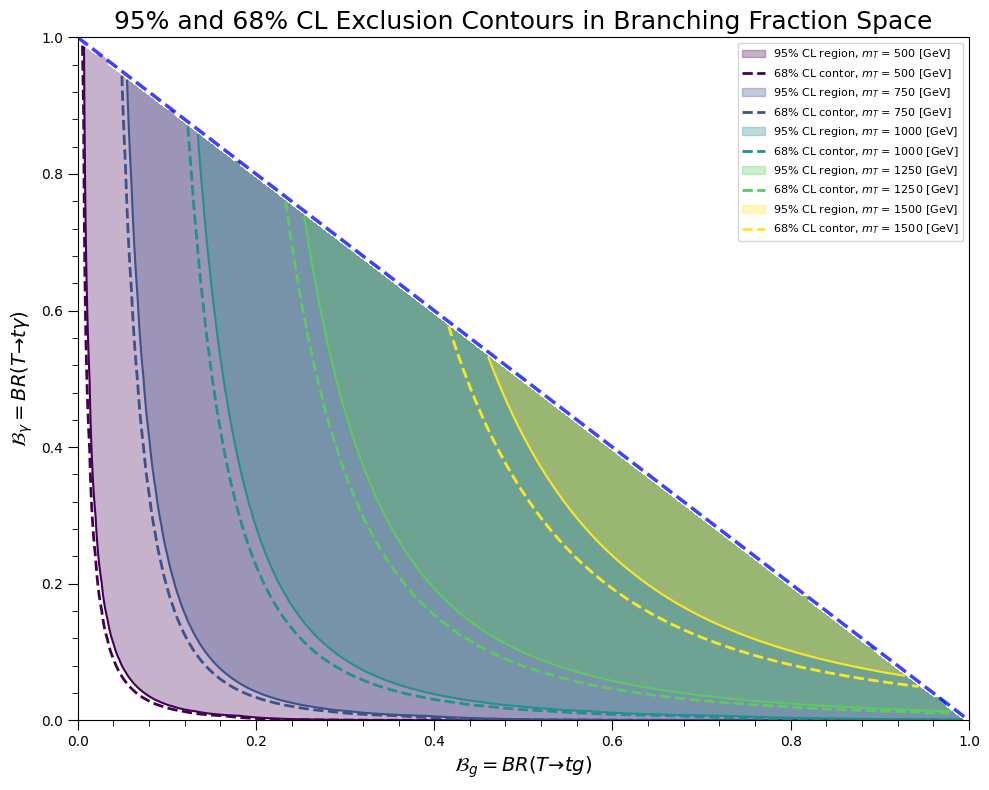

In [6]:
mass_points = [500, 750, 1000, 1250, 1500]#, 1750, 2000]
colors = plt.cm.viridis(np.linspace(0, 1, len(mass_points)))
plt.figure(figsize=(10, 8))
chi2_68 = chi2.ppf(0.68, df=11)
chi2_95 = chi2.ppf(0.95, df=11)
legend_handles = []

for i, mass in enumerate(mass_points): # 
    # compute_limit = ComputeLimit(mass)
    # compute_limit.find_contour(**dic[mass])
    compute_limit_br = ComputeLimitBR(mass)
    X, Y, Z = compute_limit_br.find_contour()
    plt.contourf(X, Y, Z, levels=[chi2_95, Z.max()], colors=[colors[i]], alpha=0.3)
    contour_95 = plt.contour(X, Y, Z, levels=[chi2_95], colors=[colors[i]], linewidths=1.5, linestyles='solid')
    contour_68 = plt.contour(X, Y, Z, levels=[chi2_68], colors=[colors[i]], linewidths=2, linestyles='dashed')
    
    patch = Patch(color=colors[i], alpha=0.3, label=f'95% CL region, $m_T$ = {mass} [GeV]')
    # line = Line2D([0], [0], color=colors[i], lw=1.5, linestyle='solid', label=f'95% CL contor, $m_T$ = {mass} [GeV]')
    line = Line2D([0], [0], color=colors[i], lw=2, linestyle='dashed', label=f'68% CL contor, $m_T$ = {mass} [GeV]')

    legend_handles.extend([patch, line])
            
x_line = np.linspace(0, 1, 100)
y_line = 1 - x_line
plt.plot(x_line, y_line, 'b--', lw=2.5, alpha=0.75, label='$\mathcal{B}_{\gamma} + \mathcal{B}_{g} \leq 1$')
    
    
ax = plt.gca() 
ax.xaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_major_locator(MultipleLocator(0.2))

ax.xaxis.set_minor_locator(MultipleLocator(0.04))
ax.yaxis.set_minor_locator(MultipleLocator(0.04))

ax.tick_params(axis='both', which='minor', length=4)
ax.tick_params(axis='both', which='major', length=7)

plt.xlabel('$\mathcal{B}_{g} = BR(T \\to tg)$', fontsize = 14)
plt.ylabel('$\mathcal{B}_{\gamma} = BR(T \\to t\gamma)$', fontsize = 14)
plt.title(f'95% and 68% CL Exclusion Contours in Branching Fraction Space', fontsize = 18)
# plt.grid()
# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.legend(handles=legend_elements)

# plt.savefig(f'plots/limit_br_{self.mass}.svg', format='svg', dpi=1200)
plt.legend(handles=legend_handles, ncol=1, loc='upper right', fontsize=8, bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(f"plots/limit_br.png")
plt.show()
    

KeyboardInterrupt: 

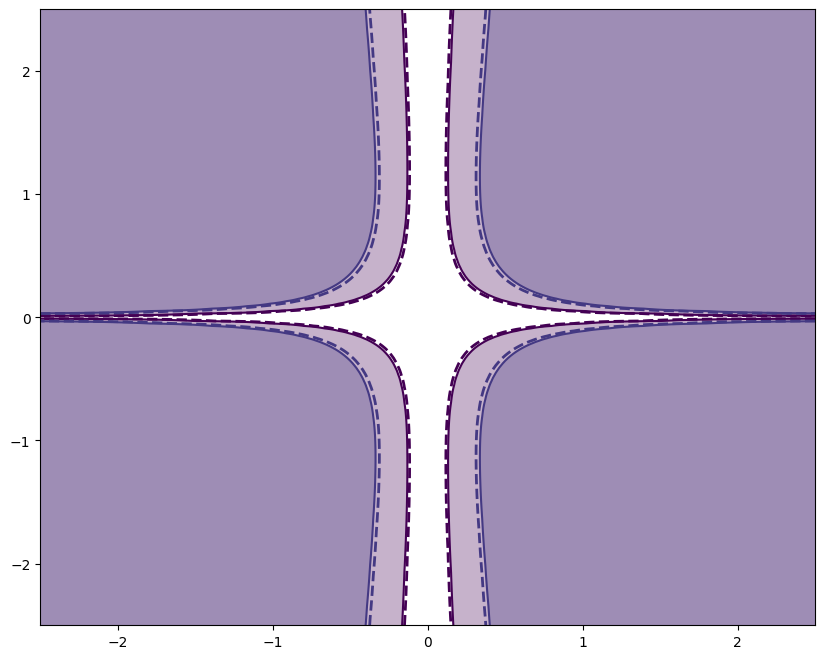

In [7]:
mass_points = [500, 750, 1000, 1250, 1500, 1750, 2000]
colors = plt.cm.viridis(np.linspace(0, 1, len(mass_points)))
plt.figure(figsize=(10, 8))
chi2_68 = chi2.ppf(0.68, df=11)
chi2_95 = chi2.ppf(0.95, df=11)
legend_handles = []

for i, mass in enumerate(mass_points): # 
    # compute_limit = ComputeLimit(mass)
    # compute_limit.find_contour(**dic[mass])
    compute_limit = ComputeLimit(mass)
    X, Y, Z = compute_limit.find_contour()
    plt.contourf(X, Y, Z, levels=[chi2_95, Z.max()], colors=[colors[i]], alpha=0.3)
    contour_95 = plt.contour(X, Y, Z, levels=[chi2_95], colors=[colors[i]], linewidths=1.5, linestyles='solid')
    contour_68 = plt.contour(X, Y, Z, levels=[chi2_68], colors=[colors[i]], linewidths=2, linestyles='dashed')
    
    patch = Patch(color=colors[i], alpha=0.3, label=f'95% CL region, $m_T$ = {mass} [GeV]')
    # line = Line2D([0], [0], color=colors[i], lw=1.5, linestyle='solid', label=f'95% CL contor, $m_T$ = {mass} [GeV]')
    line = Line2D([0], [0], color=colors[i], lw=2, linestyle='dashed', label=f'68% CL contor, $m_T$ = {mass} [GeV]')

    legend_handles.extend([patch, line])
    
# Horizontal line at y = 0
plt.axhline(0, color='black', linestyle='--', linewidth=1)
# Vertical line at x = 0
plt.axvline(0, color='black', linestyle='--', linewidth=1)
    
ax = plt.gca() 
ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.yaxis.set_major_locator(MultipleLocator(0.5))

ax.xaxis.set_minor_locator(MultipleLocator(0.1))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))

ax.tick_params(axis='both', which='minor', length=4)
ax.tick_params(axis='both', which='major', length=7)

plt.xlabel('$g_{3g} (\mathrm{TeV^{-1}})$', fontsize = 14)
plt.ylabel('$g_{3\\gamma} (\mathrm{TeV^{-1}})$', fontsize = 14)
plt.title(f'95% and 68% CL Exclusion Contours in Coupling Space', fontsize = 18)
# plt.grid()
# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.legend(handles=legend_elements)

# plt.savefig(f'plots/limit_br_{self.mass}.svg', format='svg', dpi=1200)
plt.legend(handles=legend_handles, ncol=1, loc='upper right', fontsize=8, bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(f"plots/limit_g.png")
plt.show()
    

In [ ]:
dic = {
    500: {"g3g_range": (-1, 1), "g3gamma_range": (-1, 1), "n_points": 100},
    750: {"g3g_range": (-1.5, 1.5), "g3gamma_range": (-1.5, 1.5), "n_points": 100},
    1000: {"g3g_range": (-2.5, 2.5), "g3gamma_range": (-2.5, 2.5), "n_points": 150},
    1250: {"g3g_range": (-3.5, 3.5), "g3gamma_range": (-3.5, 3.5), "n_points": 150},
    1500: {"g3g_range": (-4.5, 4.5), "g3gamma_range": (-4.5, 4.5), "n_points": 150},
    1750: {"g3g_range": (-5.5, 5.5), "g3gamma_range": (-5.5, 5.5), "n_points": 150},
    2000: {"g3g_range": (-6.5, 6.5), "g3gamma_range": (-6.5, 6.5), "n_points": 150},
}
for mass in [500, 750, 1000, 1250, 1500, 1750, 2000]: # 
    compute_limit = ComputeLimit(mass)
    compute_limit.find_contour(**dic[mass])
    compute_limit_br = ComputeLimitBR(mass)
    compute_limit_br.find_contour()